# 1. Carregando a base e bibliotecas necessárias

In [3]:
# importanto as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

import statsmodels.api as sm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# lendo a base de dados
base_credito = pd.read_csv(r'Base_ScoreCredito_QuantumFinance.csv', sep=';')

# 2. Visualizando e ajustando os a base de dados

In [5]:
# visualizando alguns dados
base_credito.head()

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778
1,708083283,58,M,solteiro,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3"
2,708084558,46,M,divorciado,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401
3,708085458,34,F,solteiro,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4"
4,708086958,49,F,casado,mestrado,2,36,0,0,3,1,437,1,2,476


In [6]:
# visualizando formatos das variáveis
base_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10127 non-null  int64 
 1   idade                10127 non-null  int64 
 2   sexo                 10127 non-null  object
 3   estado_civil         10127 non-null  object
 4   escola               10127 non-null  object
 5   Qte_dependentes      10127 non-null  int64 
 6   tempo_ultimoservico  10127 non-null  int64 
 7   trabalha             10127 non-null  int64 
 8   vl_salario_mil       10127 non-null  object
 9   reg_moradia          10127 non-null  int64 
 10  casa_propria         10127 non-null  int64 
 11  vl_imovel_em_mil     10127 non-null  int64 
 12  Qte_cartoes          10127 non-null  int64 
 13  Qte_carros           10127 non-null  int64 
 14  SCORE_CREDITO        10127 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.2+ MB


In [7]:
# Transforma a variável SCORE_CREDITO em número
base_credito['SCORE_CREDITO'] = base_credito['SCORE_CREDITO'].str.replace(',', '.').astype(float)

In [8]:
# Transforma a variável vl_salario_mil em número
base_credito['vl_salario_mil'] = base_credito['vl_salario_mil'].str.replace(',', '.').astype(float)

In [9]:
# Transforma a variável vl_salario_mil em número
base_credito['vl_imovel_em_mil'] = base_credito['vl_imovel_em_mil'].astype(float)

In [10]:
# verificando novamente os tipos das variáveis
base_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10127 non-null  int64  
 1   idade                10127 non-null  int64  
 2   sexo                 10127 non-null  object 
 3   estado_civil         10127 non-null  object 
 4   escola               10127 non-null  object 
 5   Qte_dependentes      10127 non-null  int64  
 6   tempo_ultimoservico  10127 non-null  int64  
 7   trabalha             10127 non-null  int64  
 8   vl_salario_mil       10127 non-null  float64
 9   reg_moradia          10127 non-null  int64  
 10  casa_propria         10127 non-null  int64  
 11  vl_imovel_em_mil     10127 non-null  float64
 12  Qte_cartoes          10127 non-null  int64  
 13  Qte_carros           10127 non-null  int64  
 14  SCORE_CREDITO        10127 non-null  float64
dtypes: float64(3), int64(9), object(3)
m

In [11]:
# Avaliando a quantidade de NA´s (missing)
pd.DataFrame(zip(base_credito.isnull().sum(),base_credito.isnull().sum()/len(base_credito)), columns=['Count', 'Proportion'], index=base_credito.columns)

,Count,Proportion
id,0,0.0
idade,0,0.0
sexo,0,0.0
estado_civil,0,0.0
escola,0,0.0
Qte_dependentes,0,0.0
tempo_ultimoservico,0,0.0
trabalha,0,0.0
vl_salario_mil,0,0.0
reg_moradia,0,0.0


In [12]:
# descritivo das variáveis: medidas resumo
base_credito.describe().round(2)

,id,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.0,10127.00,10127.00,10127.00
mean,7.391776e+08,46.33,1.55,34.13,0.91,70.21,3.78,0.35,209.0,1.08,0.62,469.50
std,3.690378e+07,8.02,1.49,8.22,0.28,55.57,1.58,0.48,378.5,0.33,0.57,133.81
min,7.080821e+08,26.00,0.00,7.00,0.00,0.00,1.00,0.00,0.0,1.00,0.00,162.00
25%,7.130368e+08,41.00,0.00,30.00,1.00,21.33,3.00,0.00,0.0,1.00,0.00,375.00
50%,7.179264e+08,46.00,1.00,34.00,1.00,66.49,4.00,0.00,0.0,1.00,1.00,449.60
75%,7.731435e+08,52.00,3.00,39.00,1.00,107.54,5.00,1.00,289.0,1.00,1.00,540.90
max,8.283431e+08,73.00,5.00,57.00,1.00,233.30,6.00,1.00,1800.0,4.00,2.00,979.65


# 3. Histogramas

Text(0.5, 1.0, 'Histograma Valor')

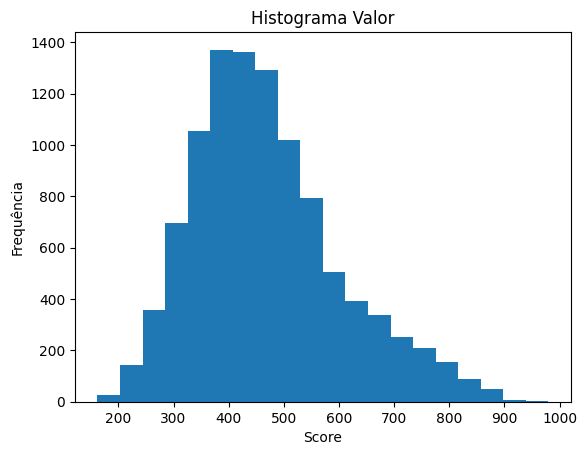

In [13]:
# Histograma da variável Variável target - SCORE_CREDITO

plt.hist(base_credito['SCORE_CREDITO'], bins=20)
plt.ylabel('Frequência')
plt.xlabel('Score')
plt.title('Histograma Valor')

Text(0.5, 1.0, 'Histograma raiz_score')

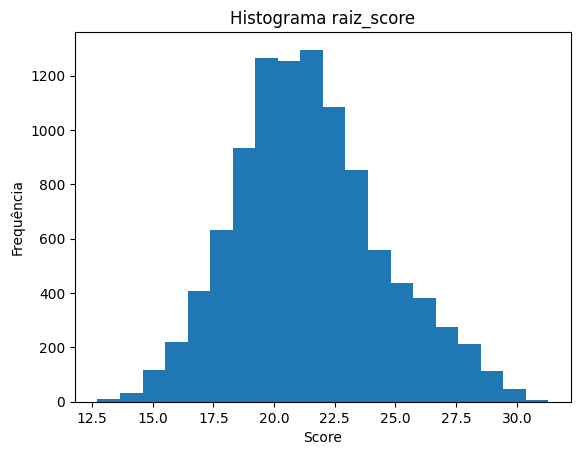

In [14]:
# Histograma da variável target após tratamento de raiz quadrada
base_credito['raiz_score'] = np.sqrt(base_credito['SCORE_CREDITO'])

# base_credito['SCORE_CREDITO'] = base_credito['raiz_score']

plt.hist(base_credito['raiz_score'], bins=20)
plt.ylabel('Frequência')
plt.xlabel('Score')
plt.title('Histograma raiz_score')

Text(0, 0.5, 'Número de casos')

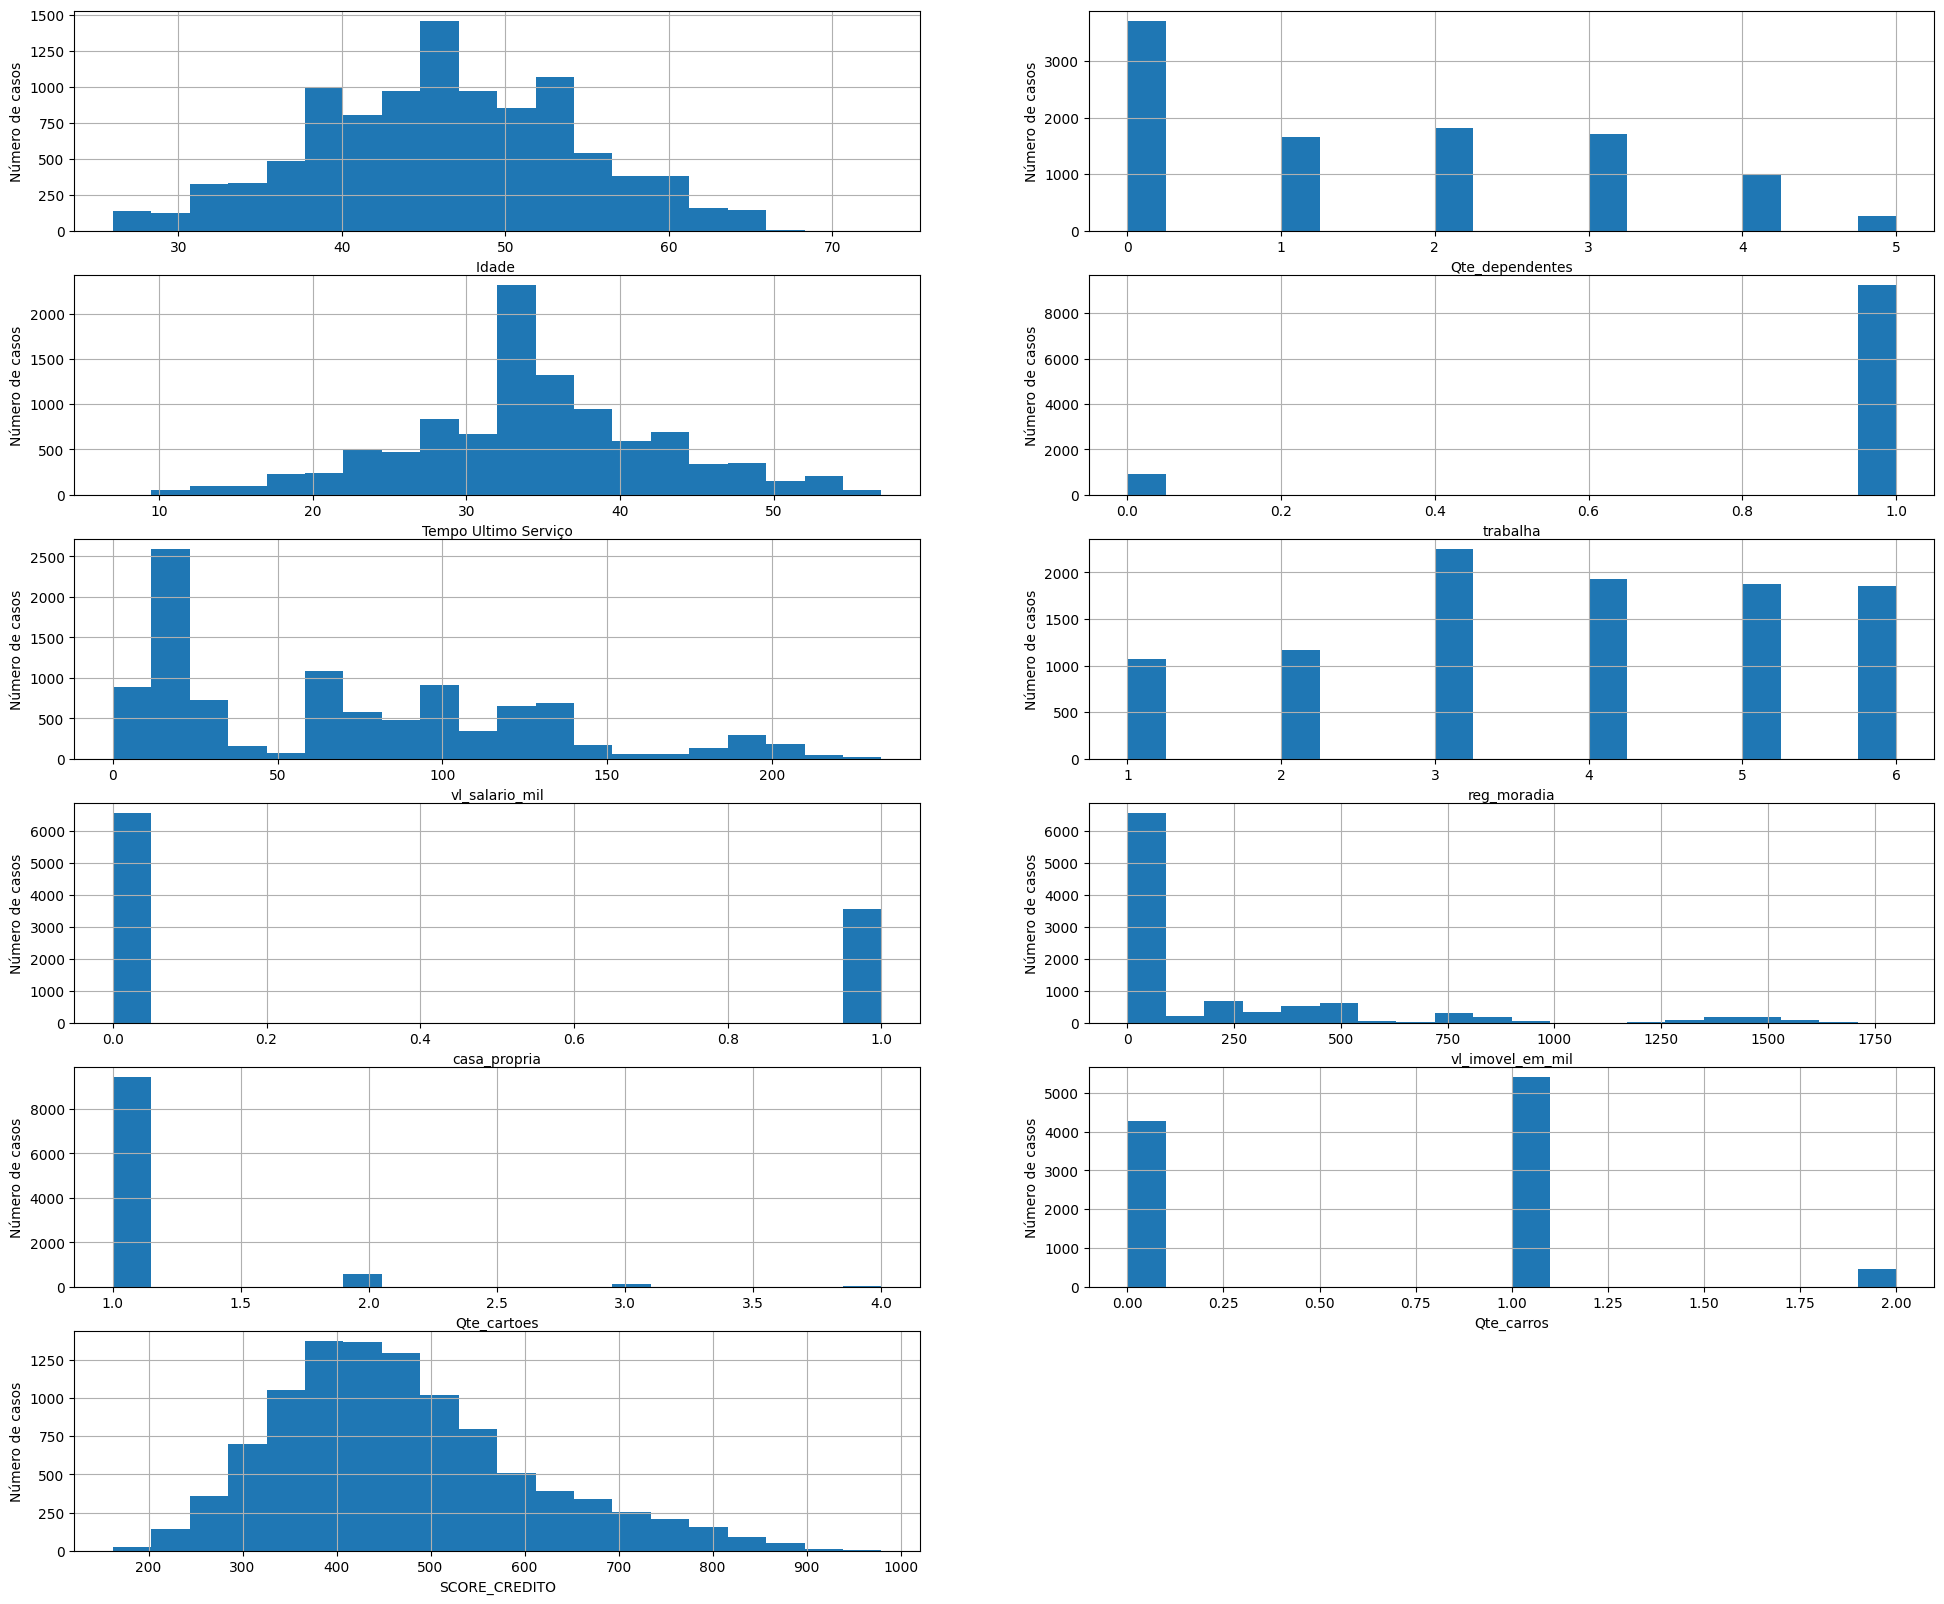

In [15]:
# avaliando a distribuição de cada variável numérica

plt.figure(figsize=(24,20))

plt.subplot(6, 2, 1)
fig = base_credito['idade'].hist(bins=20)
fig.set_xlabel('Idade ')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 2)
fig = base_credito['Qte_dependentes'].hist(bins=20)
fig.set_xlabel('Qte_dependentes')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 3)
fig = base_credito['tempo_ultimoservico'].hist(bins=20)
fig.set_xlabel('Tempo Ultimo Serviço')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 4)
fig = base_credito['trabalha'].hist(bins=20)
fig.set_xlabel('trabalha')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 5)
fig = base_credito['vl_salario_mil'].hist(bins=20)
fig.set_xlabel('vl_salario_mil')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 6)
fig = base_credito['reg_moradia'].hist(bins=20)
fig.set_xlabel('reg_moradia')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 7)
fig = base_credito['casa_propria'].hist(bins=20)
fig.set_xlabel('casa_propria')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 8)
fig = base_credito['vl_imovel_em_mil'].hist(bins=20)
fig.set_xlabel('vl_imovel_em_mil')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 9)
fig = base_credito['Qte_cartoes'].hist(bins=20)
fig.set_xlabel('Qte_cartoes')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 10)
fig = base_credito['Qte_carros'].hist(bins=20)
fig.set_xlabel('Qte_carros')
fig.set_ylabel('Número de casos')

plt.subplot(6, 2, 11)
fig = base_credito['SCORE_CREDITO'].hist(bins=20)
fig.set_xlabel('SCORE_CREDITO')
fig.set_ylabel('Número de casos')


# 4. Boxplot visualizando e identificando outliers

Text(0, 0.5, 'SCORE_CREDITO')

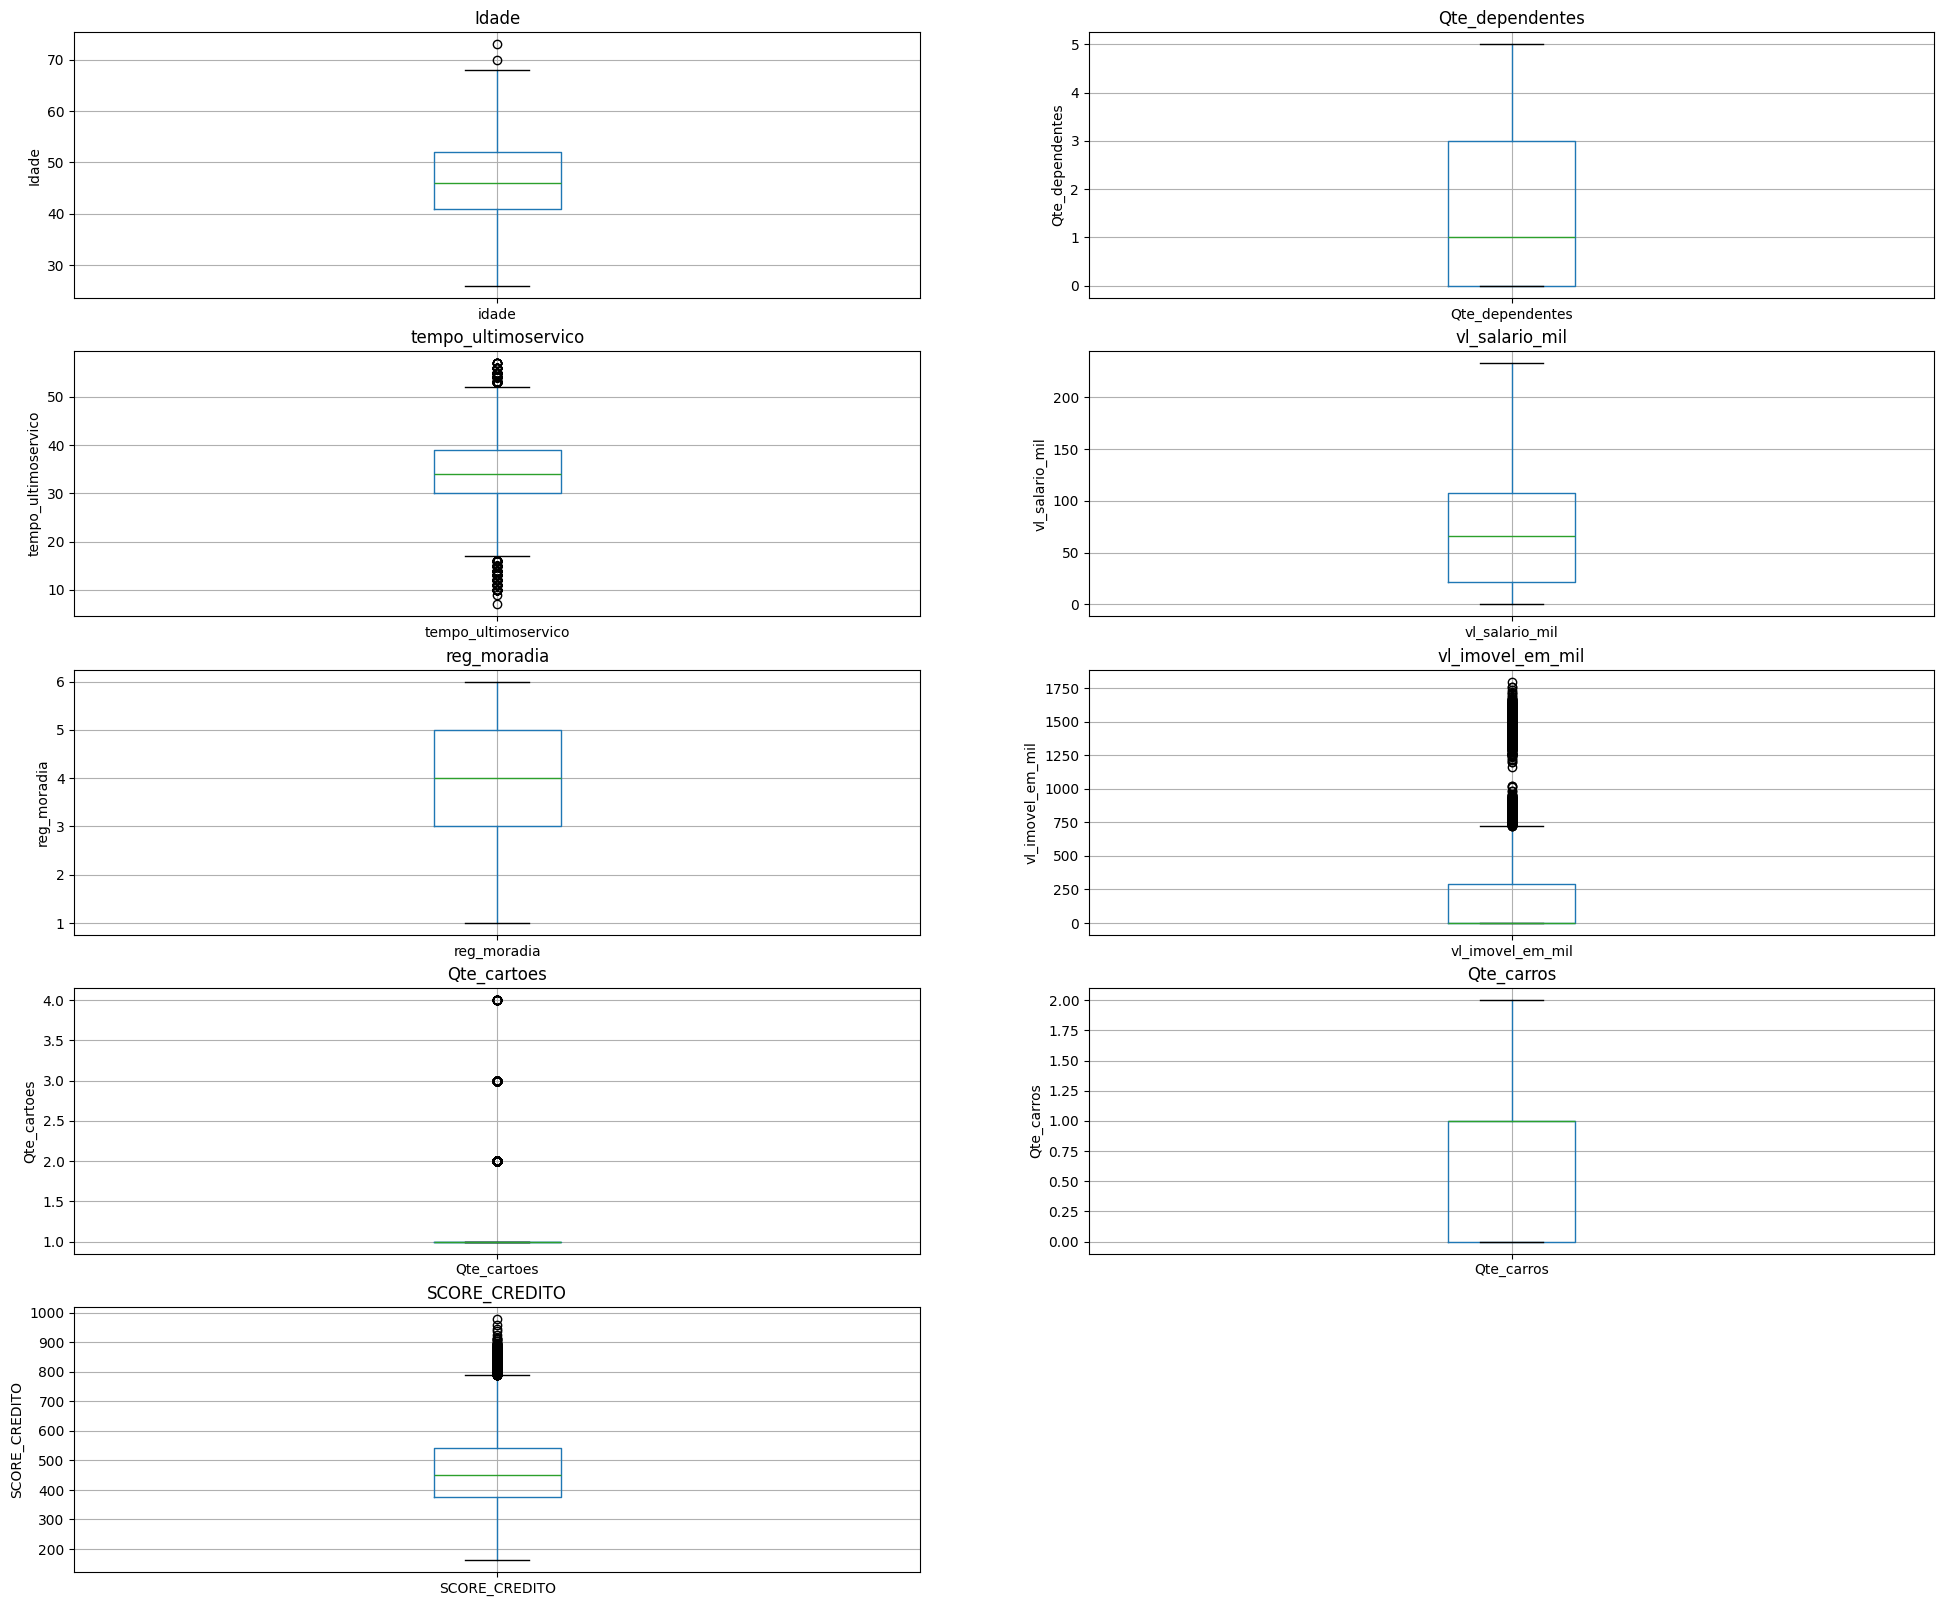

In [16]:
# Visualização de Boxplot para identificação de outliers

plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base_credito.boxplot(column='idade')
fig.set_title('Idade')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base_credito.boxplot(column='Qte_dependentes')
fig.set_title('Qte_dependentes')
fig.set_ylabel('Qte_dependentes')

plt.subplot(5, 2, 3)
fig = base_credito.boxplot(column='tempo_ultimoservico')
fig.set_title('tempo_ultimoservico')
fig.set_ylabel('tempo_ultimoservico')

#plt.subplot(6, 2, 4)
#fig = base_credito.boxplot(column='trabalha')
#fig.set_title('')
#fig.set_ylabel('trabalha')

plt.subplot(5, 2, 4)
fig = base_credito.boxplot(column='vl_salario_mil')
fig.set_title('vl_salario_mil')
fig.set_ylabel('vl_salario_mil')

plt.subplot(5, 2, 5)
fig = base_credito.boxplot(column='reg_moradia')
fig.set_title('reg_moradia')
fig.set_ylabel('reg_moradia')

#plt.subplot(6, 2, 7)
#fig = base_credito.boxplot(column='casa_propria')
#fig.set_title('')
#fig.set_ylabel('casa_propria')

plt.subplot(5, 2, 6)
fig = base_credito.boxplot(column='vl_imovel_em_mil')
fig.set_title('vl_imovel_em_mil')
fig.set_ylabel('vl_imovel_em_mil')

plt.subplot(5, 2, 7)
fig = base_credito.boxplot(column='Qte_cartoes')
fig.set_title('Qte_cartoes')
fig.set_ylabel('Qte_cartoes')

plt.subplot(5, 2, 8)
fig = base_credito.boxplot(column='Qte_carros')
fig.set_title('Qte_carros')
fig.set_ylabel('Qte_carros')

plt.subplot(5, 2, 9)
fig = base_credito.boxplot(column='SCORE_CREDITO')
fig.set_title('SCORE_CREDITO')
fig.set_ylabel('SCORE_CREDITO')

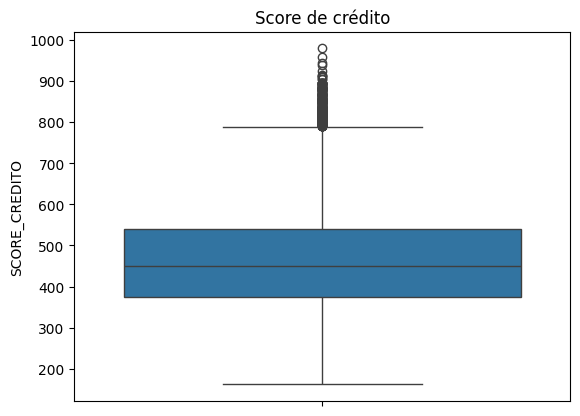

In [17]:
sb.boxplot(y='SCORE_CREDITO', data=base_credito)
plt.title('Score de crédito')
plt.show()

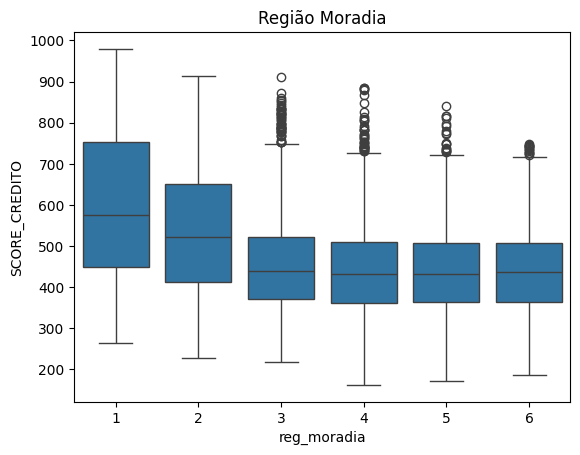

In [18]:
# Região Moradia x Score
sb.boxplot(x='reg_moradia', y='SCORE_CREDITO', data=base_credito)
plt.title('Região Moradia')
plt.show()

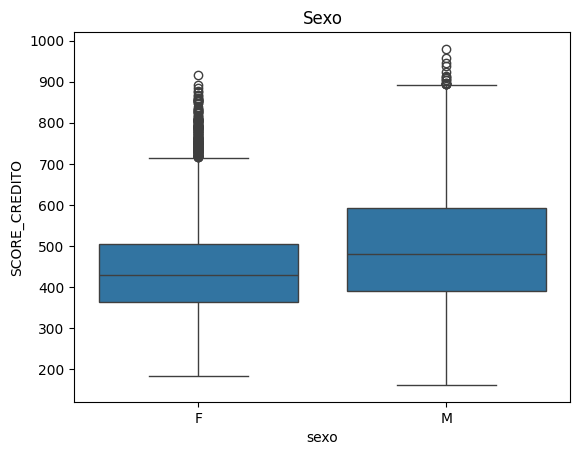

In [19]:
# Região Sexo  x Score
sb.boxplot(x='sexo', y='SCORE_CREDITO', data=base_credito)
plt.title('Sexo')
plt.show()

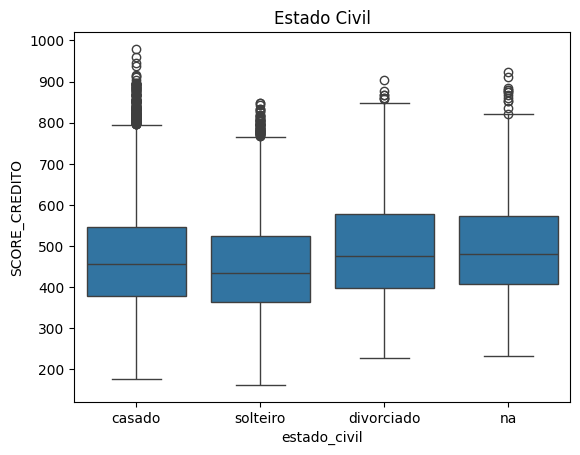

In [20]:
# Estado Civil  x Score
sb.boxplot(x='estado_civil', y='SCORE_CREDITO', data=base_credito)
plt.title('Estado Civil')
plt.show()

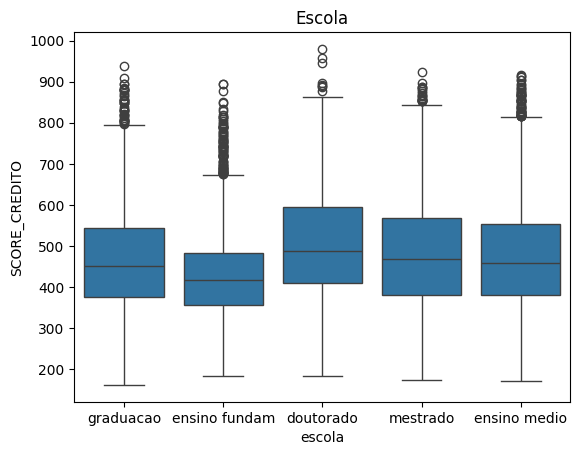

In [21]:
# Escola  x Score
sb.boxplot(x='escola', y='SCORE_CREDITO', data=base_credito)
plt.title('Escola')
plt.show()

# 5. Separando Variáveis Quantitativa e Qualitativa

In [22]:
# excluindo variáveis auxiliares que não são necessárias
base_credito = base_credito.drop(['id', 'raiz_score'], axis = 1)
base_credito.head()

# Separando Variáveis Quantitativa e Qualitativa
base_credito_qualitativa = base_credito[["sexo", "estado_civil", "escola", 'reg_moradia']]
base_credito_quantitativa = base_credito.drop(["sexo", "estado_civil", "escola", 'reg_moradia'], axis=1)

display(base_credito_qualitativa)
display(base_credito_quantitativa)

,sexo,estado_civil,escola,reg_moradia
0,F,casado,graduacao,3
1,M,solteiro,ensino fundam,3
2,M,divorciado,doutorado,6
3,F,solteiro,mestrado,6
4,F,casado,mestrado,3
...,...,...,...,...
10122,M,casado,mestrado,4
10123,M,solteiro,ensino fundam,6
10124,F,casado,graduacao,3
10125,M,casado,ensino medio,4


,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,45,3,40,1,40.089665,0,0.0,1,1,778.0
1,58,0,44,1,66.557645,0,0.0,1,0,276.3
2,46,3,35,1,123.681821,0,0.0,1,1,401.0
3,34,0,22,1,19.715934,0,0.0,1,0,347.4
4,49,2,36,0,0.000000,1,437.0,1,2,476.0
...,...,...,...,...,...,...,...,...,...,...
10122,50,0,45,1,100.128971,0,0.0,1,0,470.0
10123,38,0,31,1,89.805996,0,0.0,1,1,432.0
10124,49,3,43,1,19.799306,1,252.0,1,1,406.0
10125,54,4,48,1,194.783176,0,0.0,1,1,387.0


# 6 Analise de correlação das variáveis

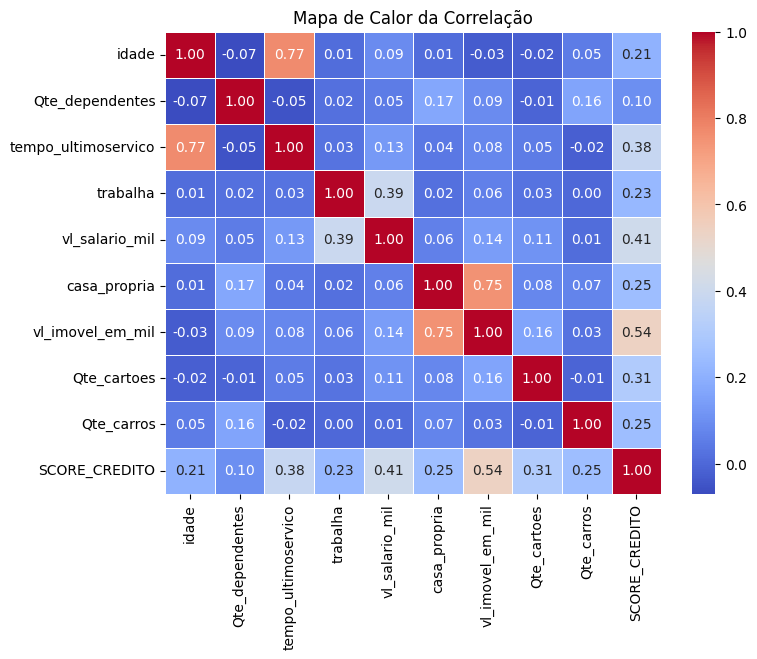

In [23]:
# Correlação de Pearson - quando as variáveis são núméricas quantitativas
# ρ = 0,9 a 1 (positivo ou negativo): correlação muito forte;
# ρ = 0,7 a 0,9 (positivo ou negativo): correlação forte;
# ρ = 0,5 a 0,7 (positivo ou negativo): correlação moderada;
# ρ = 0,3 a 0,5 (positivo ou negativo): correlação fraca;
# ρ = 0 a 0,3 (positivo ou negativo): não possui correlação.

correlacao = base_credito_quantitativa.corr().round(2)

# Gerar o heatmap
plt.figure(figsize=(8, 6))
sb.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Exibir gráfico
plt.title("Mapa de Calor da Correlação")
plt.show()

# 7. Analise descritiva: Variáveis dependentes x target 

Text(0.5, 1.0, 'Scatter plot Valor versus Valor Imóvel (mil)')

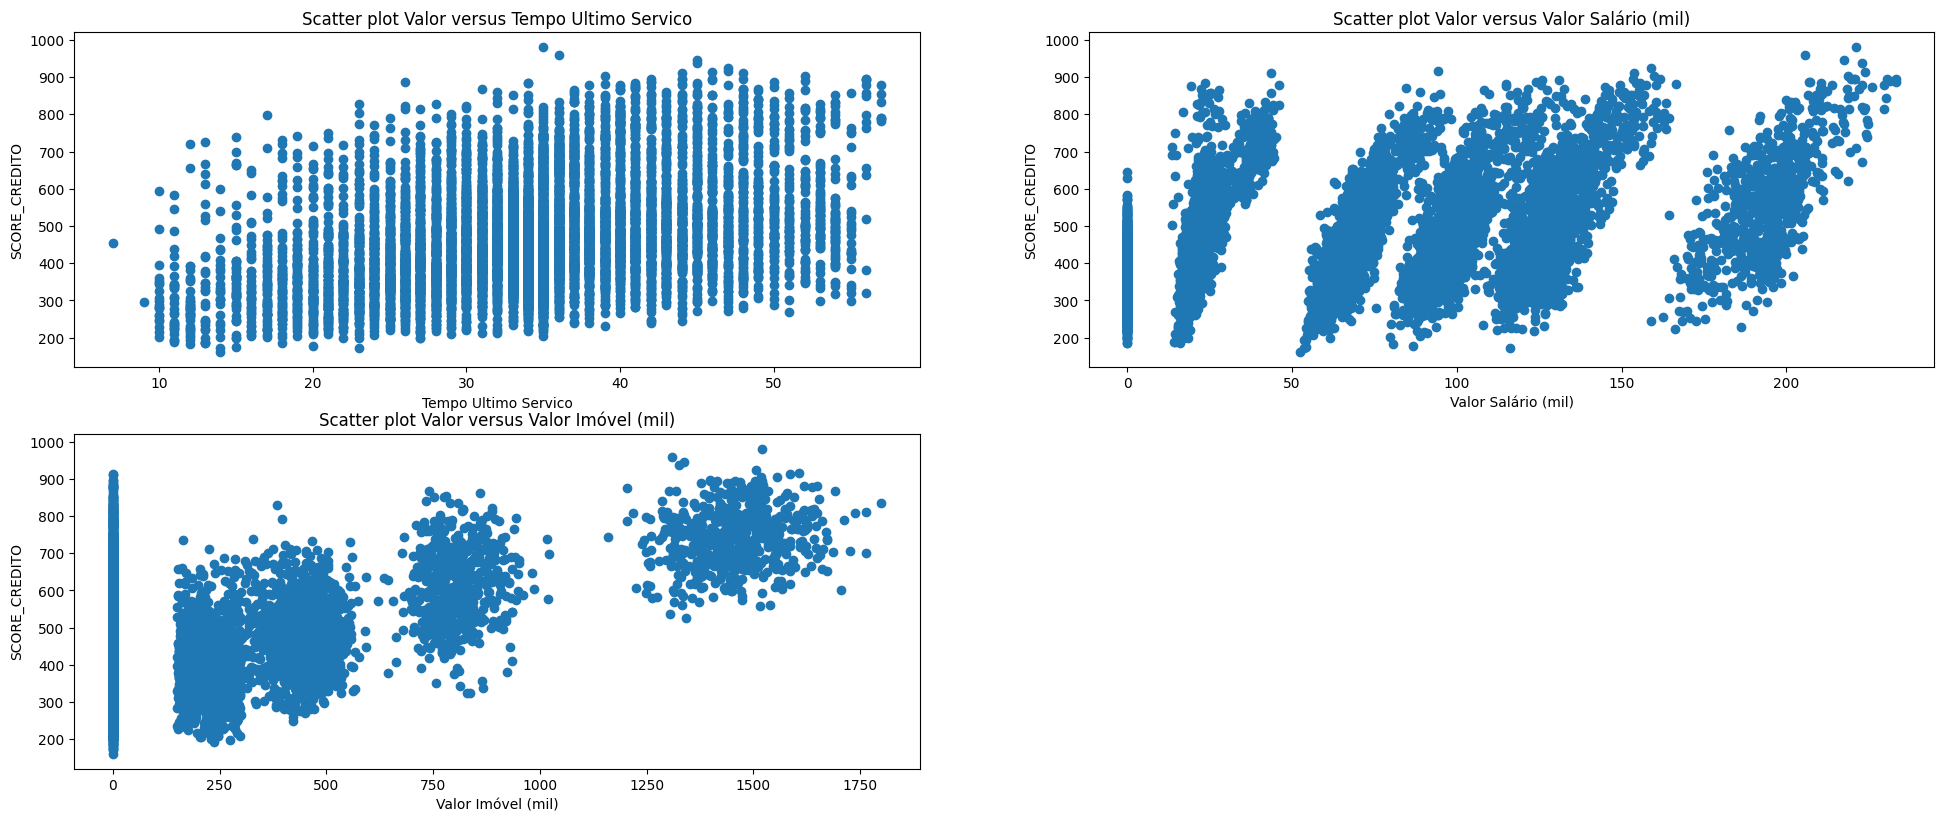

In [24]:
# gráfico quando a variável preditora quantitativa

# Gráfico de dispersão
plt.figure(figsize=(24,20))

plt.subplot(4, 2, 1)
xg = 'tempo_ultimoservico'
lg = 'Tempo Ultimo Servico'
plt.scatter(xg, 'SCORE_CREDITO', data=base_credito)
plt.xlabel(lg)
plt.ylabel("SCORE_CREDITO")
plt.title(f"Scatter plot Valor versus {lg}")

plt.subplot(4, 2, 2)
xg = 'vl_salario_mil'
lg = 'Valor Salário (mil)'
plt.scatter(xg, 'SCORE_CREDITO', data=base_credito)
plt.xlabel(lg)
plt.ylabel("SCORE_CREDITO")
plt.title(f"Scatter plot Valor versus {lg}")

plt.subplot(4, 2, 3)
xg = 'vl_imovel_em_mil'
lg = 'Valor Imóvel (mil)'
plt.scatter(xg, 'SCORE_CREDITO', data=base_credito)
plt.xlabel(lg)
plt.ylabel("SCORE_CREDITO")
plt.title(f"Scatter plot Valor versus {lg}")

# 8. Variáveis Preditoras/Independentes quantitativas com a variável Target

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sexo          10127 non-null  object
 1   estado_civil  10127 non-null  object
 2   escola        10127 non-null  object
 3   reg_moradia   10127 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 316.6+ KB


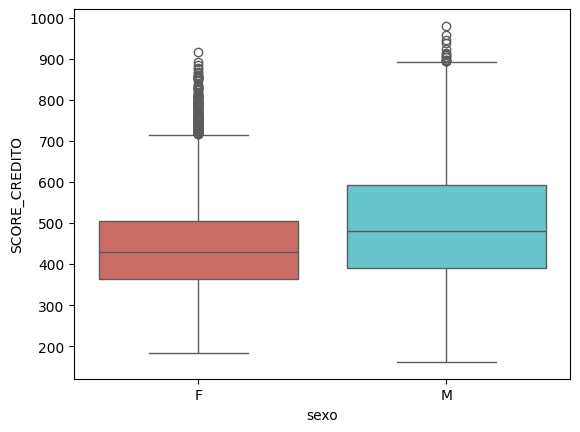

In [25]:
# Variáveis qualitativa com a variável Target
# Boxplot da variável SCORE_CREDITO versus a variável sexo
sb.boxplot(x='sexo', y='SCORE_CREDITO', data=base_credito, palette='hls')

base_credito_qualitativa.info()

<Axes: xlabel='estado_civil', ylabel='SCORE_CREDITO'>

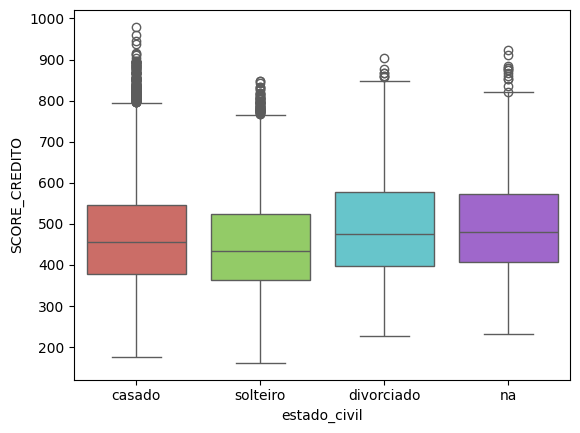

In [26]:
# Variáveis qualitativa com a variável Target
# Boxplot da variável SCORE_CREDITO versus a variável estado_civil
sb.boxplot(x='estado_civil', y='SCORE_CREDITO', data=base_credito, palette='hls')

<Axes: xlabel='escola', ylabel='SCORE_CREDITO'>

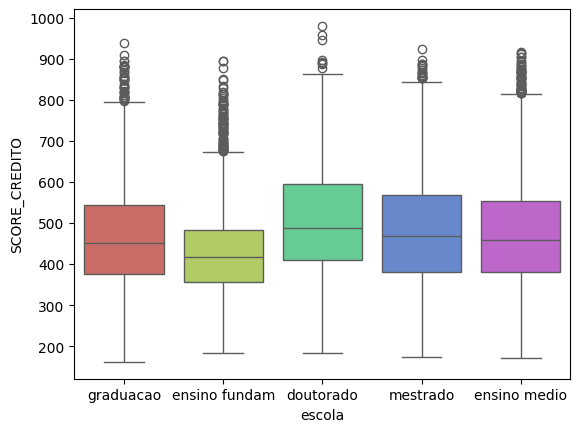

In [27]:
# Variáveis qualitativa com a variável Target
# Boxplot da variável SCORE_CREDITO versus a variável escola
sb.boxplot(x='escola', y='SCORE_CREDITO', data=base_credito, palette='hls')

<Axes: xlabel='trabalha', ylabel='SCORE_CREDITO'>

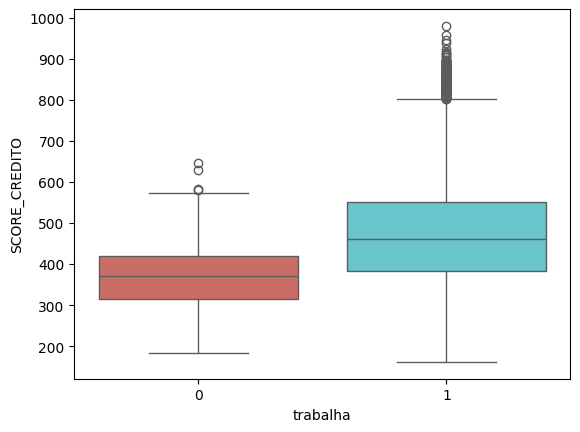

In [28]:
# Variáveis qualitativa com a variável Target
# Boxplot da variável SCORE_CREDITO versus a variável trabalha
sb.boxplot(x='trabalha', y='SCORE_CREDITO', data=base_credito, palette='hls')

<Axes: xlabel='reg_moradia', ylabel='SCORE_CREDITO'>

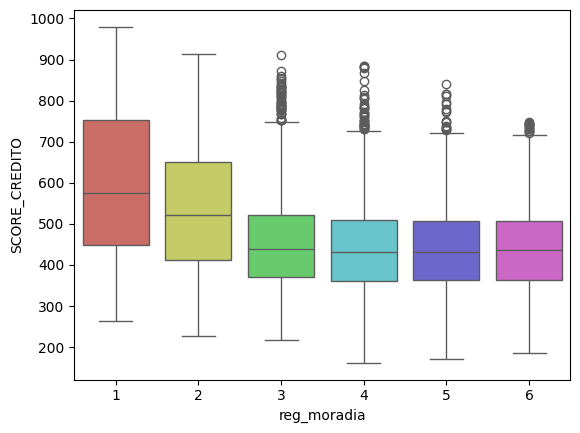

In [29]:
# Variáveis qualitativa com a variável Target
# Boxplot da variável SCORE_CREDITO versus a variável reg_moradia
sb.boxplot(x='reg_moradia', y='SCORE_CREDITO', data=base_credito, palette='hls')

<Axes: xlabel='casa_propria', ylabel='SCORE_CREDITO'>

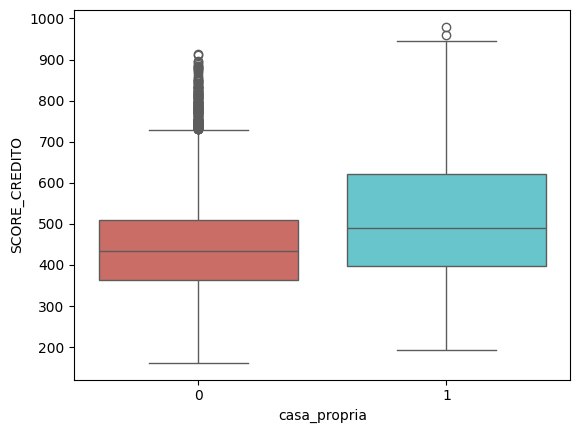

In [30]:
# Variáveis qualitativa com a variável Target
# Boxplot da variável SCORE_CREDITO versus a variável casa_propria
sb.boxplot(x='casa_propria', y='SCORE_CREDITO', data=base_credito, palette='hls')

# 9. Convertendo variáveis qualitativas em Dummies

### 9.1 Sexo

In [31]:
# Transformando sexo em true / false, deixa somente a coluna Masculino
masculino = pd.get_dummies(base_credito_qualitativa['sexo'],drop_first=True)
masculino.head()

,M
0,False
1,True
2,True
3,False
4,False


### 9.2 Estado Civil

In [32]:
# Substitui os valores na por "Solteiro"
estado_civil = base_credito_qualitativa["estado_civil"].replace("na", "solteiro")
estado_civil.value_counts()

estado_civil
solteiro      4692
casado        4687
divorciado     748
Name: count, dtype: int64

In [33]:
# Cria variável dummies para 'estado civil', exclui variável casado
estado_civil = pd.get_dummies(estado_civil, drop_first=True)
estado_civil.head()

,divorciado,solteiro
0,False,False
1,False,True
2,True,False
3,False,True
4,False,False


In [34]:
estado_civil.head()

,divorciado,solteiro
0,False,False
1,False,True
2,True,False
3,False,True
4,False,False


### 9.3 Escolaridade

In [35]:
# Convertendo escolaridade para uma variável numérica (Decidimos não fazer Dummies, pois pode ser uma quantitativa ordinal)
escola = {"ensino medio": 0, "ensino fundam": 1, "graduacao": 2, "mestrado": 3, "doutorado": 4}
escolaridade = pd.DataFrame(base_credito_qualitativa["escola"].replace(escola), columns=["escola"])

escolaridade

,escola
0,2
1,1
2,4
3,3
4,3
...,...
10122,3
10123,1
10124,2
10125,0


### 9.4 Região moradia

In [36]:
# Cria dummies para 'região moradia'
regiao = pd.get_dummies(base_credito_qualitativa['reg_moradia'], drop_first=True)
regiao.head()

,2,3,4,5,6
0,False,True,False,False,False
1,False,True,False,False,False
2,False,False,False,False,True
3,False,False,False,False,True
4,False,True,False,False,False


# 10. Criando nova base com variáveis qualitativas ajustadas

In [37]:
base_credito_final = pd.concat([masculino, estado_civil, escolaridade, regiao, base_credito_quantitativa], axis=1)
display(base_credito_final.head())

base_credito_final.info()

,M,divorciado,solteiro,escola,2,3,4,5,6,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,False,False,False,2,False,True,False,False,False,45,3,40,1,40.089665,0,0.0,1,1,778.0
1,True,False,True,1,False,True,False,False,False,58,0,44,1,66.557645,0,0.0,1,0,276.3
2,True,True,False,4,False,False,False,False,True,46,3,35,1,123.681821,0,0.0,1,1,401.0
3,False,False,True,3,False,False,False,False,True,34,0,22,1,19.715934,0,0.0,1,0,347.4
4,False,False,False,3,False,True,False,False,False,49,2,36,0,0.000000,1,437.0,1,2,476.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   M                    10127 non-null  bool   
 1   divorciado           10127 non-null  bool   
 2   solteiro             10127 non-null  bool   
 3   escola               10127 non-null  int64  
 4   2                    10127 non-null  bool   
 5   3                    10127 non-null  bool   
 6   4                    10127 non-null  bool   
 7   5                    10127 non-null  bool   
 8   6                    10127 non-null  bool   
 9   idade                10127 non-null  int64  
 10  Qte_dependentes      10127 non-null  int64  
 11  tempo_ultimoservico  10127 non-null  int64  
 12  trabalha             10127 non-null  int64  
 13  vl_salario_mil       10127 non-null  float64
 14  casa_propria         10127 non-null  int64  
 15  vl_imovel_em_mil     10127 non-null 

# 11. Etapa de pré processamento e preparação da base

In [38]:
# Ajustando nome das colunas para evitar erros nos modelos

colunas_para_renomear = [2, 3, 4, 5, 6]  # Nomes das colunas como int
novos_nomes = ["r2", "r3", "r4", "r5", "r6"]

# 1. Converter nomes de colunas para str
base_credito_final.columns = base_credito_final.columns.astype(str)

# 2. Criar dicionário de mapeamento (agora com chaves como str)
mapa_de_renomeacao = dict(zip(map(str, colunas_para_renomear), novos_nomes))

# 3. Renomear as colunas
base_credito_final = base_credito_final.rename(columns=mapa_de_renomeacao)

In [39]:
# Separa valores do Eixo X (Variáveis independentes) do Eixo Y (Variável target)
X = base_credito_final[base_credito_final.columns[0:18]]
y = base_credito_final['SCORE_CREDITO']

In [40]:
X

,M,divorciado,solteiro,escola,r2,r3,r4,r5,r6,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros
0,False,False,False,2,False,True,False,False,False,45,3,40,1,40.089665,0,0.0,1,1
1,True,False,True,1,False,True,False,False,False,58,0,44,1,66.557645,0,0.0,1,0
2,True,True,False,4,False,False,False,False,True,46,3,35,1,123.681821,0,0.0,1,1
3,False,False,True,3,False,False,False,False,True,34,0,22,1,19.715934,0,0.0,1,0
4,False,False,False,3,False,True,False,False,False,49,2,36,0,0.000000,1,437.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,True,False,False,3,False,False,True,False,False,50,0,45,1,100.128971,0,0.0,1,0
10123,True,False,True,1,False,False,False,False,True,38,0,31,1,89.805996,0,0.0,1,1
10124,False,False,False,2,False,True,False,False,False,49,3,43,1,19.799306,1,252.0,1,1
10125,True,False,False,0,False,False,True,False,False,54,4,48,1,194.783176,0,0.0,1,1


In [41]:
y

0        778.0
1        276.3
2        401.0
3        347.4
4        476.0
         ...  
10122    470.0
10123    432.0
10124    406.0
10125    387.0
10126    513.0
Name: SCORE_CREDITO, Length: 10127, dtype: float64

In [42]:
# Separa bade de treino da base de testes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 21)

# 12. Stats model - regressão linear múltipla

### 12.1 Teste-01 - Usando todas as variáveis

In [43]:
# Modelo de regressão linear múltipla
# regression.linear_model.OLS Ordinary Least Squares
X_ = sm.add_constant(X_train)

X_

,const,M,divorciado,solteiro,escola,r2,r3,r4,r5,r6,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros
7865,1.0,True,False,True,3,True,False,False,False,False,50,0,37,1,141.178777,1,844.0,1,1
2010,1.0,False,False,True,1,False,False,False,False,True,47,0,38,1,18.648461,0,0.0,1,0
4461,1.0,True,False,False,1,False,False,False,False,True,56,1,35,1,130.709087,0,0.0,1,0
8033,1.0,False,True,False,0,False,False,False,False,True,40,2,21,0,0.000000,0,0.0,1,1
1924,1.0,True,False,False,3,False,True,False,False,False,54,4,39,1,137.643539,1,482.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9336,1.0,False,False,True,2,False,False,False,True,False,52,0,45,1,21.469908,0,0.0,1,0
48,1.0,True,False,True,3,False,True,False,False,False,41,1,27,1,119.905778,0,0.0,1,1
8964,1.0,False,False,True,0,False,False,False,True,False,55,0,34,1,67.853483,0,0.0,1,0
5944,1.0,False,False,False,1,False,False,False,False,False,31,0,28,1,21.042817,1,1454.0,2,1


In [44]:
# Aplicando o modelo
model_OLS = sm.OLS(y_train, X_.astype(float)).fit()

print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     754.4
Date:                Sun, 23 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:11:31   Log-Likelihood:                -40954.
No. Observations:                7088   AIC:                         8.195e+04
Df Residuals:                    7069   BIC:                         8.208e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 141.8625    

### 12.2 Teste-02 - Removendo variáveis não significantes
- Removemos toda a categoria das dummies que apresentaram P > 0.05

In [45]:
# Removendo as variáveis não significantes P > 0.05
X_train2, X_test2, y_train2, y_test2 = train_test_split(X.drop(['solteiro', 'divorciado', "r2", "r3", "r4", "r5", "r6"], axis=1), y, test_size=0.3, random_state=21)

In [46]:
# Aplicando o modelo

X2_ = sm.add_constant(X_train2)
model_fim2 = sm.OLS(y_train2, X2_.astype(float)).fit()
print(model_fim2.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     1207.
Date:                Sun, 23 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:11:31   Log-Likelihood:                -41008.
No. Observations:                7088   AIC:                         8.204e+04
Df Residuals:                    7076   BIC:                         8.212e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 112.2913    

### 12.3 Teste-03 (Scaler)
- Tentativa de realizar um scaler para tentar melhorar a performance do modelo

In [47]:
# Aplicando o robust scaler
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.3, random_state=21)
 
scaler = RobustScaler().fit(X_train3)
 
X_train4 = scaler.transform(X_train3)
X_test4 = scaler.transform(X_test3)

In [48]:
# Aplicando o modelo
X4_ = sm.add_constant(X_train4)
model_fim3 = sm.OLS(y_train3, X4_.astype(float)).fit()
print(model_fim3.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     754.4
Date:                Sun, 23 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:11:31   Log-Likelihood:                -40954.
No. Observations:                7088   AIC:                         8.195e+04
Df Residuals:                    7069   BIC:                         8.208e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        504.3979      6.024     83.725      0.0

In [49]:
# Calculando o valor predito da variável resposta na amostra treino
y_train_pred = model_OLS.predict(X_)


In [50]:
y_train_pred

7865    624.376234
2010    388.479695
4461     424.64004
8033    336.055584
1924    565.630316
           ...    
9336    427.332872
48      488.977781
8964     388.74401
5944    742.408848
5327    418.061211
Length: 7088, dtype: object

In [51]:
# Medidas de erro na amostra treino
me1   = round((y_train-y_train_pred).mean(),2)
print('Erro Médio (Mean error-ME):', me1)
mae1  = round((mean_absolute_error(y_train, y_train_pred)),2)
print('Erro Médio Absoluto (Mean Absolut Error-MAE):', mae1)
mse1  =round( (mean_squared_error(y_train, y_train_pred)),2)
print('Erro Quadrático Médio (Mean Squared Error-MSE)::', mse1)
rmse1  = round((np.sqrt(mean_squared_error(y_train, y_train_pred))),2)
print('Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE):', rmse1)
mpe1  = round(((y_train - y_train_pred)/y_train).mean(),2)
print('Erro Percentual Médio (Mean Percent Error-MPE):', mpe1)
mape1  =  round((mae1/y_train).mean(),2)
print('Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE):', mape1)

Erro Médio (Mean error-ME): -0.0
Erro Médio Absoluto (Mean Absolut Error-MAE): 59.93
Erro Quadrático Médio (Mean Squared Error-MSE):: 6111.39
Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE): 78.18
Erro Percentual Médio (Mean Percent Error-MPE): -0.03
Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE): 0.14


In [52]:
# Construção de diagnóstico para os gráficos

modelo_ajust_y = model_OLS.fittedvalues # Valores do modelo ajustados

modelo_residuos = model_OLS.resid # Residuos

modelo_norm_resid = model_OLS.get_influence().resid_studentized_internal # Residuos normalizados

modelo_norm_resid_abs = np.sqrt(np.abs(modelo_norm_resid)) # Quadrados dos residuos normalizados

modelo_outliers = model_OLS.get_influence().hat_matrix_diag # Outliers

distancia_cook = model_OLS.get_influence().cooks_distance[0] # Distancia de Cook


In [53]:
modelo_ajust_y

7865    624.376234
2010    388.479695
4461    424.640040
8033    336.055584
1924    565.630316
           ...    
9336    427.332872
48      488.977781
8964    388.744010
5944    742.408848
5327    418.061211
Length: 7088, dtype: float64

In [54]:
modelo_residuos

7865     18.223766
2010    -47.379695
4461   -106.640040
8033     19.944416
1924    -27.630316
           ...    
9336     54.167128
48      -69.577781
8964   -108.844010
5944     85.591152
5327    -75.061211
Length: 7088, dtype: float64

In [55]:
modelo_norm_resid

array([ 0.23305023, -0.60569396, -1.36365439, ..., -1.39184413,
        1.09619543, -0.96013326], shape=(7088,))

In [56]:
# um dataframe com a variável observado e estimado pelo modelo
dataframe = pd.concat([y_train, modelo_ajust_y], axis=1)

In [57]:
dataframe

,SCORE_CREDITO,0
7865,642.6,624.376234
2010,341.1,388.479695
4461,318.0,424.640040
8033,356.0,336.055584
1924,538.0,565.630316
...,...,...
9336,481.5,427.332872
48,419.4,488.977781
8964,279.9,388.744010
5944,828.0,742.408848


Text(0, 0.5, 'Estimado')

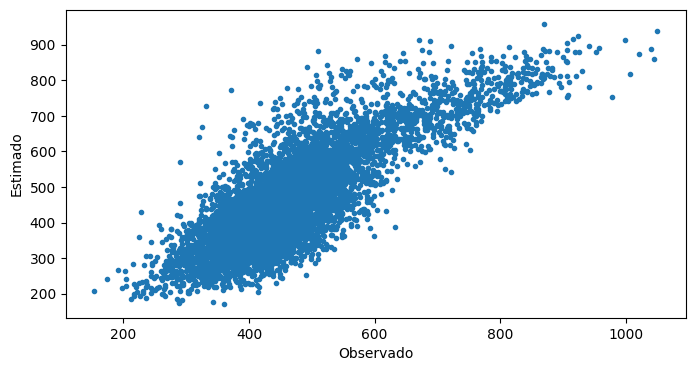

In [58]:
# Construção de diagnóstico para os gráficos
plt.figure(figsize=(8, 4))
plt.scatter(y_train_pred ,y_train, marker='.')
plt.xlabel("Observado")
plt.ylabel("Estimado")

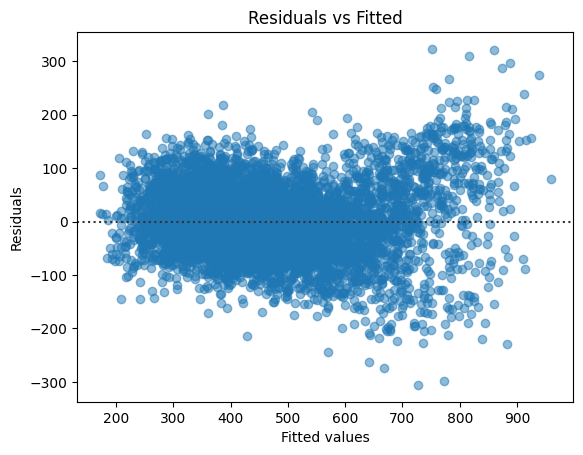

In [59]:
### Teste de Linearidade
### Nestes gráficos a presença de um padrão nos resíduos pode indicar um problema com algum aspecto do modelo linear.
plot_lm_1 = plt.figure()
plot_lm_1 = sb.residplot(data=dataframe, x=dataframe.columns[-0], y=modelo_ajust_y,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

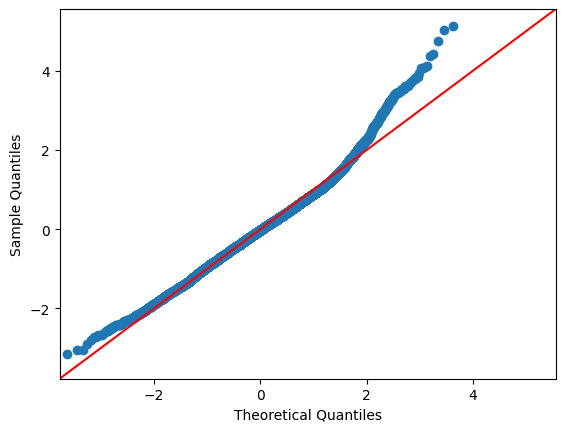

In [60]:
### Teste de Normalidade
### O gráfico de resíduos pode ser usado para verificar visualmente a suposição de normalidade.
### Sendo que para que se aceite que os resíduos estão normalmente distribuidos deve seguir aproximadamente uma linha reta.

plot_lm_2  = sm.qqplot(modelo_norm_resid, line='45')
plt.show()


In [61]:
shapiro_test = stats.shapiro(modelo_norm_resid)
shapiro_test
#(statistic, p-value)

c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7088.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9846967962837776), pvalue=np.float64(5.379805723375009e-27))

In [62]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)
# Predict the y values corresponding to X_test_sm
y_pred = model_OLS.predict(X_test_sm)

In [63]:
y_pred

7061    397.404817
9075    385.347384
7608    602.798893
1384    418.787885
6871    513.629253
           ...    
5974    468.996174
4148    442.915006
1729    556.878374
216     422.399462
9360    526.375185
Length: 3039, dtype: object

# 13. Regressão linear múltipla



In [64]:
X

,M,divorciado,solteiro,escola,r2,r3,r4,r5,r6,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros
0,False,False,False,2,False,True,False,False,False,45,3,40,1,40.089665,0,0.0,1,1
1,True,False,True,1,False,True,False,False,False,58,0,44,1,66.557645,0,0.0,1,0
2,True,True,False,4,False,False,False,False,True,46,3,35,1,123.681821,0,0.0,1,1
3,False,False,True,3,False,False,False,False,True,34,0,22,1,19.715934,0,0.0,1,0
4,False,False,False,3,False,True,False,False,False,49,2,36,0,0.000000,1,437.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,True,False,False,3,False,False,True,False,False,50,0,45,1,100.128971,0,0.0,1,0
10123,True,False,True,1,False,False,False,False,True,38,0,31,1,89.805996,0,0.0,1,1
10124,False,False,False,2,False,True,False,False,False,49,3,43,1,19.799306,1,252.0,1,1
10125,True,False,False,0,False,False,True,False,False,54,4,48,1,194.783176,0,0.0,1,1


In [65]:
y

0        778.0
1        276.3
2        401.0
3        347.4
4        476.0
         ...  
10122    470.0
10123    432.0
10124    406.0
10125    387.0
10126    513.0
Name: SCORE_CREDITO, Length: 10127, dtype: float64

In [66]:
# Regressão linear múltipla
from sklearn.linear_model import LinearRegression

#Criando um Objeto de Regressão Linear
lr = LinearRegression()

In [67]:
#Separando os dados de Treino e Teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

In [68]:
# Treinando o Modelo
lr.fit(X_train, y_train)

LinearRegression()

In [69]:
# Primeiro, vamos olhar o Intercepto e os Coeficientes da Regressão.
print('Intercepto:', lr.intercept_)

Intercepto: 141.8625350614547


In [70]:
# coeficientes
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(lr.coef_))], axis = 1)
coefficients.columns=(['Variáveis','coefficients'])

coefficients

,Variáveis,coefficients
0,M,-19.418194
1,divorciado,18.391062
2,solteiro,1.806446
3,escola,1.629921
4,r2,-4.197486
5,r3,-5.721870
6,r4,-34.123138
7,r5,-36.788342
8,r6,-37.689174
9,idade,-1.397740


In [71]:
# Calculando o valor predito da variável resposta na amostra teste
y_test_pred = lr.predict(X_test)

In [72]:
#Verificando o resultado
r_sq = lr.score(X, y)
print('Coeficiente de Determinação (R²):', r_sq)

Coeficiente de Determinação (R²): 0.6578778043519269


#### Performance do Modelo


In [73]:
y_test_pred

array([397.40481715, 385.34738376, 602.79889335, ..., 556.87837376,
       422.39946186, 526.37518529], shape=(3039,))

In [74]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Reg_lin  = (np.sqrt(mean_squared_error(y_test, y_test_pred))).round(2)

print('Erro médio quadrático:', rmse_Reg_lin)


Erro médio quadrático: 78.48


# 14. Arvore de Regressão

In [75]:
# Fit regression model
model_2 = DecisionTreeRegressor(max_depth=10, min_samples_split=100, random_state=21, criterion='squared_error')

In [76]:
model_2

DecisionTreeRegressor(max_depth=10, min_samples_split=100, random_state=21)

In [77]:
cols = X_train.columns

In [78]:
cols

Index(['M', 'divorciado', 'solteiro', 'escola', 'r2', 'r3', 'r4', 'r5', 'r6',
       'idade', 'Qte_dependentes', 'tempo_ultimoservico', 'trabalha',
       'vl_salario_mil', 'casa_propria', 'vl_imovel_em_mil', 'Qte_cartoes',
       'Qte_carros'],
      dtype='object')

In [79]:
# Treinando o modelo de arvore de decisão:

model_2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_split=100, random_state=21)

[Text(0.634077380952381, 0.9545454545454546, 'vl_imovel_em_mil <= 584.0\nsquared_error = 17850.408\nsamples = 7088\nvalue = 468.333'),
 Text(0.3586309523809524, 0.8636363636363636, 'vl_salario_mil <= 20.964\nsquared_error = 12586.658\nsamples = 6312\nvalue = 442.962'),
 Text(0.49635416666666665, 0.9090909090909092, 'True  '),
 Text(0.15714285714285714, 0.7727272727272727, 'tempo_ultimoservico <= 28.5\nsquared_error = 5667.04\nsamples = 1668\nvalue = 367.211'),
 Text(0.07142857142857142, 0.6818181818181818, 'Qte_carros <= 0.5\nsquared_error = 4251.137\nsamples = 484\nvalue = 321.555'),
 Text(0.0380952380952381, 0.5909090909090909, 'vl_salario_mil <= 17.379\nsquared_error = 3508.328\nsamples = 236\nvalue = 295.811'),
 Text(0.01904761904761905, 0.5, 'tempo_ultimoservico <= 16.5\nsquared_error = 2733.432\nsamples = 129\nvalue = 271.811'),
 Text(0.009523809523809525, 0.4090909090909091, 'squared_error = 1005.592\nsamples = 26\nvalue = 234.029'),
 Text(0.02857142857142857, 0.4090909090909091

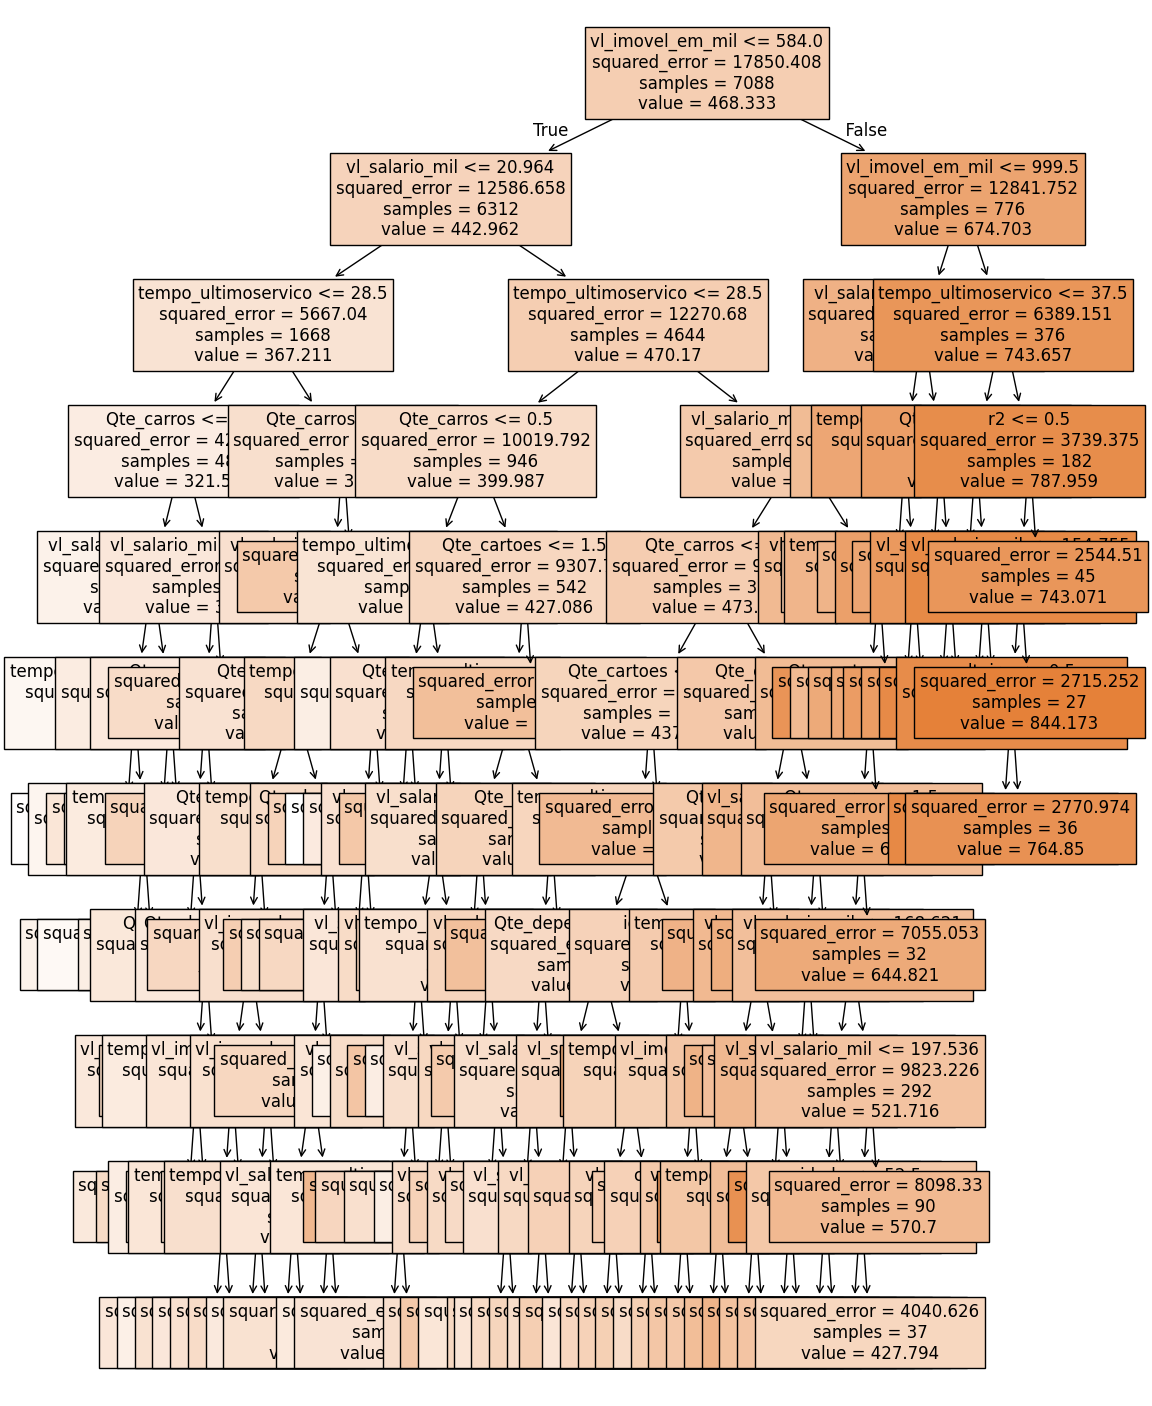

In [80]:
input_features=['M', 'divorciado', 'solteiro', 'escola', 'r2', 'r3', 'r4', 'r5', 'r6',
       'idade', 'Qte_dependentes', 'tempo_ultimoservico', 'trabalha',
       'vl_salario_mil', 'casa_propria', 'vl_imovel_em_mil', 'Qte_cartoes',
       'Qte_carros']

fig = plt.figure(figsize=(12, 18))
plot_tree(model_2, fontsize=12, filled=True, feature_names=input_features )

In [81]:
for caracteristica, score in zip(X_train, model_2.feature_importances_):
  print('caracteristica {} e Importância {}'.format(caracteristica, score*100))

caracteristica M e Importância 0.0
caracteristica divorciado e Importância 0.0
caracteristica solteiro e Importância 0.18250458005848877
caracteristica escola e Importância 0.0
caracteristica r2 e Importância 0.13416506949274104
caracteristica r3 e Importância 0.0
caracteristica r4 e Importância 0.0
caracteristica r5 e Importância 0.0
caracteristica r6 e Importância 0.0
caracteristica idade e Importância 1.491680455241291
caracteristica Qte_dependentes e Importância 0.3859105877452603
caracteristica tempo_ultimoservico e Importância 12.513361919188851
caracteristica trabalha e Importância 0.03269893485639789
caracteristica vl_salario_mil e Importância 26.473676416788777
caracteristica casa_propria e Importância 0.3047207885628551
caracteristica vl_imovel_em_mil e Importância 45.668480079229106
caracteristica Qte_cartoes e Importância 4.2059630058522295
caracteristica Qte_carros e Importância 8.606838162984007


In [82]:
# Aplicando o algoritmo na base teste
y_test_regtree  = model_2.predict(X_test)

In [83]:
y_test_regtree

array([397.15648855, 353.57931034, 549.20097087, ..., 601.80357143,
       461.89966044, 498.12998379], shape=(3039,))

In [84]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Arv_Regr  = (np.sqrt(mean_squared_error(y_test, y_test_regtree))).round(2)

print('Erro médio quadrático da Árvore de Regressão:',rmse_Arv_Regr  )


Erro médio quadrático da Árvore de Regressão: 75.93


### lembrando .. e qual era da Regressão Linear?

In [85]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Reg_lin  = (np.sqrt(mean_squared_error(y_test, y_test_pred))).round(2)

print('Erro médio quadrático da Regressão Linear:', rmse_Reg_lin)


Erro médio quadrático da Regressão Linear: 78.48
